# Titanic: Kaggle Competition

In [1]:
import os
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, train_test_split)
from sklearn.preprocessing import (LabelEncoder, StandardScaler)
from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, roc_auc_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


In [2]:
cwd  = os.getcwd()
path = os.path.join(cwd, 'data')

df_train = pd.read_csv(os.path.join(path,'train.csv')).set_index('PassengerId')
df_test  = pd.read_csv(os.path.join(path,'test.csv')).set_index('PassengerId')

df_test.sample(5)


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
965,1,"Ovies y Rodriguez, Mr. Servando",male,28.5,0,0,PC 17562,27.7208,D43,C
1094,1,"Astor, Col. John Jacob",male,47.0,1,0,PC 17757,227.5250,C62 C64,C
1107,1,"Head, Mr. Christopher",male,42.0,0,0,113038,42.5000,B11,S
1155,3,"Klasen, Miss. Gertrud Emilia",female,1.0,1,1,350405,12.1833,NaN,S
1270,1,"Hipkins, Mr. William Edward",male,55.0,0,0,680,50.0000,C39,S


# EDA

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [4]:
df_train.describe(include='all')

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [5]:
def show_missing(df):
    #Returns a DataFrame of columns that have missing values
    missing = pd.DataFrame(
        {'count': df.isna().sum(),
             '%':(df.isna().mean() * 100).round(2)})

    return missing[missing['count'] > 0].sort_values('%', ascending=False)


In [6]:
print('train')
display(show_missing(df_train))
print('test')
display(show_missing(df_test))


train


,count,%
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


test


,count,%
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


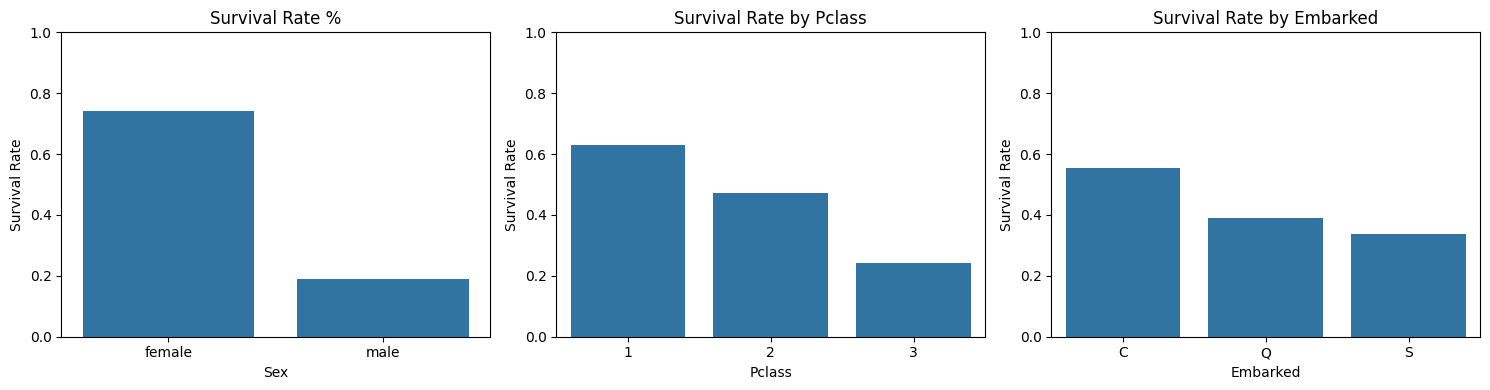

In [7]:
# try sns for plotting in this HW
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, title) in zip(axes, [
    ('Sex',      'Survival Rate %'),
    ('Pclass',   'Survival Rate by Pclass'),
    ('Embarked', 'Survival Rate by Embarked'),
]):
    data = df_train.groupby(col, as_index=False)['Survived'].mean()
    sns.barplot(data=data, x=col, y='Survived', ax=ax)
    
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()


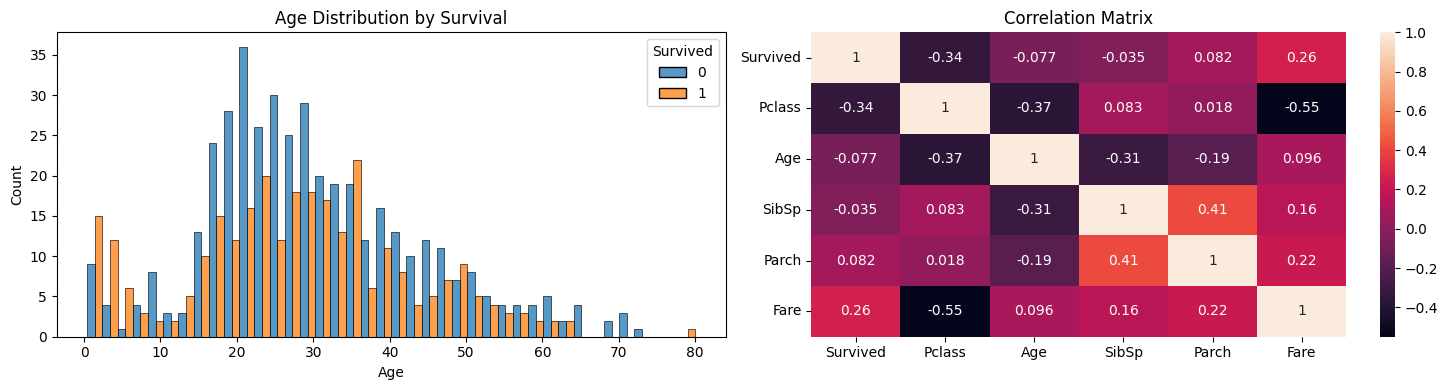

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(data=df_train, x='Age', hue='Survived', bins=40,
             multiple='dodge', ax=axes[0])
axes[0].set_title('Age Distribution by Survival')

# heatmap
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
sns.heatmap(df_train[corr_cols].corr(), annot=True,
            ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()


# Cleaning

In [9]:
def clean_data(df_train, df_test):
    """
    Fill missing values and drop bad columns 
    """
    df_train, df_test = df_train.copy(), df_test.copy()

    #median for age and fare, it is more robust to outliers than mean
    df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())
    df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())

    df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())
    #mode for embarked, fill with most common value
    df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])

    drop_cols = ['Name', 'Ticket', 'Cabin']
    return df_train.drop(columns=drop_cols), df_test.drop(columns=drop_cols)

df_train_clean, df_test_clean = clean_data(df_train, df_test)
display(show_missing(df_train_clean))


,count,%


# Encoding

In [10]:
def encode_features(df_train, df_test):
    """
    LabelEncode categorical columns. 
    Fit on train, transform on test - no data leakage
    """
    df_train, df_test = df_train.copy(), df_test.copy()

    cat_cols = df_train.select_dtypes(include='str').columns

    for col in cat_cols:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        df_test[col]  = le.transform(df_test[col])

    return df_train, df_test

df_train_enc, df_test_enc = encode_features(df_train_clean, df_test_clean)
df_train_enc.dtypes

Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object

# train-test split

In [11]:
X = df_train_enc.drop(columns=['Survived'])
y = df_train_enc['Survived']

X_submission = df_test_enc # prediction for submission, no target column

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y)

print(f'Train: {X_train.shape}, Test: {X_test.shape}, Submission: {X_submission.shape}')

Train: (668, 7), Test: (223, 7), Submission: (418, 7)


## Base Model XGBoost with default param

In [12]:
base_xgb = XGBClassifier(random_state=0, 
                         eval_metric='logloss', 
                         device='cpu', 
                         verbosity=0)
                         
base_xgb.fit(X_train, y_train)

trained_models = {'XGBoost Base': base_xgb}

print('train accuracy:', accuracy_score(y_train, base_xgb.predict(X_train)))
print('test accuracy:', accuracy_score(y_test, base_xgb.predict(X_test)))

train accuracy: 0.9745508982035929
test accuracy: 0.8295964125560538


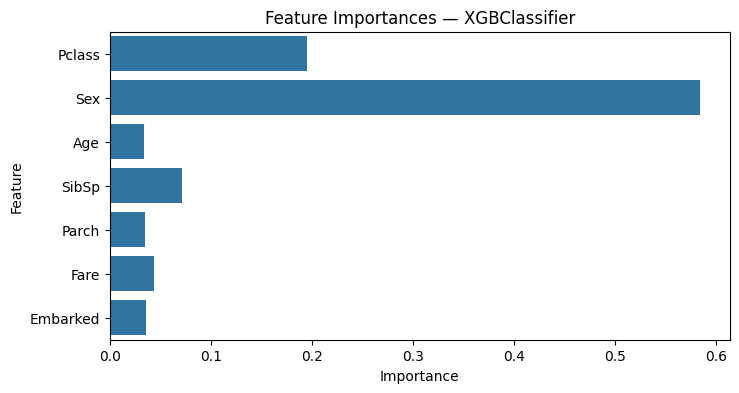

In [13]:
# In this lesson i try to use sns for plotting
def plot_feature_importance(clf, feature_names):
    """
    Horizontal barplot of feature importances
    In case of top_n, shows only top_n features
    """
    imp = pd.Series(clf.feature_importances_, index=feature_names)
    plt.figure(figsize=(8,4))
    sns.barplot(x=imp.values, y=imp.index)
    plt.title(f'Feature Importances — {clf.__class__.__name__}')
    plt.ylabel('Feature')
    plt.xlabel('Importance')
    plt.show()

plot_feature_importance(base_xgb, X_train.columns)

# Models comparison
idea about this func i got from lesson_8, maybe a lil overkill

In [18]:
def run_all_models(X_train, X_test, y_train, y_test, cv_splits=5, random_state=0):
    """
    GridSearchCV for 6 classifiers in a Pipeline
    """
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    # stratified to keep class balance in folds, shuffle for randomness

    configs = [
        ('LogisticRegression',
         Pipeline([('scaler', StandardScaler()),
                   ('clf', LogisticRegression(max_iter=10000, random_state=random_state))]),
         {'clf__C': [0.005, 0.1, 1, 5, 10],
          'clf__class_weight': [None, 'balanced']}),

        ('RandomForest',
         Pipeline([('clf', RandomForestClassifier(random_state=random_state))]),
         {'clf__n_estimators': [300, 600],
          'clf__max_depth': [None, 4, 6, 8],
          'clf__min_samples_split': [2, 5, 10],
          }),

        ('GradientBoosting',
         Pipeline([('clf', GradientBoostingClassifier(random_state=random_state))]),
         {'clf__n_estimators':  [100, 200],
          'clf__max_depth':     [3, 5],
          'clf__learning_rate': [0.05, 0.1, 0.2]}),

        ('XGBoost',
         Pipeline([('clf', XGBClassifier(random_state=random_state,
                                         eval_metric='logloss', device='cpu', verbosity=0))]),
         {'clf__n_estimators':     [100, 200],
          'clf__max_depth':        [3, 5, 7],
          'clf__learning_rate':    [0.05, 0.1],
          'clf__subsample':        [0.8, 1.0],
          'clf__colsample_bytree': [0.8, 1.0]}),

        ('SVC',
         Pipeline([('scaler', StandardScaler()),
                   ('clf', SVC(kernel='rbf', probability=True, random_state=random_state))]),
         {'clf__C':     [0.1, 1, 10, 100],
          'clf__gamma': ['scale', 'auto', 0.01, 0.1]}),

        ('MLP',
         Pipeline([('scaler', StandardScaler()),
                   ('clf', MLPClassifier(max_iter=10000, random_state=random_state))]),
         {'clf__hidden_layer_sizes': [(50,), (100,), (100, 50)],
          'clf__alpha':              [0.001, 0.01, 0.1]}),
    ]

    """
    code below runs GridSearchCV for each model, 
    collects metrics and best estimators in a DataFrame and dict
    """
    
    rows, fitted = [], {}

    for name, pipeline, param_grid in configs:
        t0 = time.time() # start timer

        grid = GridSearchCV(pipeline, param_grid, scoring='accuracy',
                            cv=cv, refit=True, n_jobs=-1, verbose=0)
        grid.fit(X_train, y_train)
        elapsed = time.time() - t0 # end timer

        y_test_pred = grid.predict(X_test)
        y_test_prob = grid.predict_proba(X_test)[:, 1]
        fitted[name] = grid.best_estimator_

        row = {
            'Model': name,
            #'Best Params': {k.replace('clf__', ''): v for k, v in grid.best_params_.items()},
            #'CV acc': round(grid.best_score_,4), #
            'Train': round(accuracy_score(y_train, grid.predict(X_train)), 4),
            'Test ': round(accuracy_score(y_test, y_test_pred), 4),
            'Precision': round(precision_score(y_test, y_test_pred), 4),
            'Recall': round(recall_score(y_test, y_test_pred), 4),
            'Test F1': round(f1_score(y_test, y_test_pred),4),
            'Test ROC-AUC': round(roc_auc_score(y_test, y_test_prob),4),
            'Time (s)': round(elapsed, 1),}
        
        rows.append(row)

    df = pd.DataFrame(rows).sort_values('Test ', ascending=False).reset_index(drop=True)
    return df, fitted

In [20]:
results, model_candidates = run_all_models(X_train, X_test, y_train, y_test)
trained_models.update(model_candidates)

In [21]:
results

,Model,Train,Test,Precision,Recall,Test F1,Test ROC-AUC,Time (s)
0,GradientBoosting,0.9386,0.8430,0.8696,0.6977,0.7742,0.8512,2.4
1,RandomForest,0.8473,0.8206,0.8966,0.6047,0.7222,0.8362,10.4
2,XGBoost,0.8653,0.8161,0.8689,0.6163,0.7211,0.8464,1.6
3,SVC,0.8443,0.8117,0.8056,0.6744,0.7342,0.8173,0.9
4,MLP,0.8623,0.7892,0.7910,0.6163,0.6928,0.8277,8.4
5,LogisticRegression,0.8039,0.7758,0.7308,0.6628,0.6951,0.8349,0.3


# Submission
Pick the best model from trained_models and generate the Kaggle CSV.

on kaggle:
xgboost(78_229)|RandomForest(78_229)|SVC(78_468)|MLP(77_511)|LogisticRegression(75_837)|GradientBoosting(72_727)

In [22]:
# here i can choose which model to submit, if [0] - it will choose the best one by test accuracy
best_name = results.iloc[3]['Model'] #by pinging kaggle i found that SVC has best score
best_clf  = trained_models[best_name]
print(f'Submitting with: {best_name}')

predictions = best_clf.predict(X_submission)

output = pd.DataFrame({
    'PassengerId': X_submission.index,
    'Survived':    predictions.astype(int)
})

filepath = os.path.join(path, 'submission.csv')
output.to_csv(filepath, index=False)

output.head()

Submitting with: SVC


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## Results
![score](/Users/macbook/code/Amazinum_HW/lesson_8_supervised_ml/data/Screenshot_kaggle.png)